# 1. Classification

## Question 1

In [1]:
import pandas as pd

dr = pd.read_csv("data.csv", delimiter=";")
dr.head()


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [2]:
from pandas import DataFrame


X: DataFrame = dr.drop("Target", axis=1)
y: pd.Series = dr["Target"].factorize()[0]
X, y

(      Marital status  Application mode  Application order  Course  \
 0                  1                17                  5     171   
 1                  1                15                  1    9254   
 2                  1                 1                  5    9070   
 3                  1                17                  2    9773   
 4                  2                39                  1    8014   
 ...              ...               ...                ...     ...   
 4419               1                 1                  6    9773   
 4420               1                 1                  2    9773   
 4421               1                 1                  1    9500   
 4422               1                 1                  1    9147   
 4423               1                10                  1    9773   
 
       Daytime/evening attendance\t  Previous qualification  \
 0                                1                       1   
 1                              

## Question 2

## Question 3

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
print(f"Random Forest initial accuracy: train {rf.score(X_train, y_train)} / test {rf.score(X_test, y_test)}")

Random Forest initial accuracy: train 1.0 / test 0.7674943566591422


## Question 4

In [10]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
print(f"Random Forest initial accuracy (random_state): train {rf.score(X_train, y_train)} / test {rf.score(X_test, y_test)}")

Random Forest initial accuracy (random_state): train 1.0 / test 0.7720090293453724


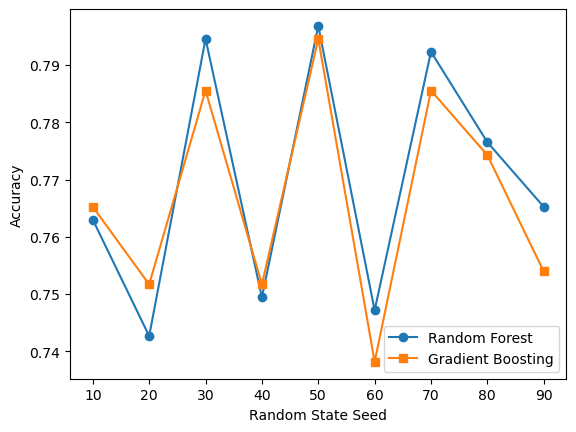

In [19]:
from sklearn.ensemble import GradientBoostingClassifier 

rf_accuracies = []
gb_accuracies = []
seed_range = [10, 20, 30, 40, 50, 60, 70, 80, 90]

for seed in seed_range:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=seed)
    # Random Forest
    rf_tmp = RandomForestClassifier()
    rf_tmp.fit(X_train, y_train)
    rf_accuracies.append(rf_tmp.score(X_test, y_test))

    # Gradient Boosting
    gb_tmp = GradientBoostingClassifier()
    gb_tmp.fit(X_train, y_train)
    gb_accuracies.append(gb_tmp.score(X_test, y_test))

import matplotlib.pyplot as plt

plt.plot(seed_range, rf_accuracies, label='Random Forest', marker='o')
plt.plot(seed_range, gb_accuracies, label='Gradient Boosting', marker='s')
plt.xlabel('Random State Seed')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Question 5

## Question 6

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.99, random_state=seed)

# Gradient Boosting
gb_tmp = GradientBoostingClassifier()
gb_tmp.fit(X_train, y_train)
print("Gradient Boosting Accuracy with 1% training data:", gb_tmp.score(X_test, y_test))

Gradient Boosting Accuracy with 0.: 0.504337899543379


# 2. Regression

## Question 7

In [ ]:
measurements = pd.read_csv("measurements.csv", delimiter=',')

col_x, col_y = measurements.columns[0], measurements.columns[1]

X = measurements[[col_x]].values
y = measurements[col_y].values

lin_model = LinearRegression()
lin_model.fit(X, y)

y_pred_lin = lin_model.predict(X)

mse_lin = mean_squared_error(y, y_pred_lin)
r2_lin  = r2_score(y, y_pred_lin)

print(f'Régression linéaire')
print(f'Coefficient : {lin_model.coef_[0]:.4f}')
print(f'Intercept : {lin_model.intercept_:.4f}')
print(f'MSE : {mse_lin:.4f}')
print(f'R²: {r2_lin}')

## Interprétation des résultats

##### MSE
- L'erreur absolue moyenne est relativement proche de 0 (0.49), ce qui veut dire qu'en moyenne les points sont proches de l'estimation linéaire faite.

#### R²
- Le coefficient de regression linéaire est proche de 1 (0.874), donc c'est un bon modèle

## Question 8

In [ ]:
degrees = [2, 8, 25]
colors  = ['seagreen', 'darkorange', 'purple']

results = []
x_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

fig, axes = plt.subplots(1, len(degrees), figsize=(16, 5), sharey=False)

for ax, deg, color in zip(axes, degrees, colors):
    poly_model = make_pipeline(
        PolynomialFeatures(degree=deg, include_bias=False),
        LinearRegression()
    )
    poly_model.fit(X, y)

    y_pred = poly_model.predict(X)
    mse    = mean_squared_error(y, y_pred)
    r2     = r2_score(y, y_pred)
    results.append({'Degré': deg, 'MSE': mse, 'R²': r2})

    y_curve = poly_model.predict(x_plot)

    ax.scatter(X, y, color='steelblue', alpha=0.6, edgecolors='white', s=25, linewidths=0.3)
    ax.plot(x_plot, y_curve, color=color, linewidth=2)
    ax.set_title(f'Degré {deg}\nMSE={mse:.2f}  R²={r2:.4f}', fontsize=11)
    ax.set_xlabel(col_x)
    ax.set_ylabel(col_y)

plt.suptitle('Régression polynomiale - comparaison des degrés', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

df_results = pd.DataFrame([{'Degré': 1, 'MSE': mse_lin, 'R²': r2_lin}] + results)
print(df_results.to_string(index=False))

In [ ]:
all_degrees = [1, 2, 8, 25]
mse_vals = df_results['MSE'].values
r2_vals  = df_results['R²'].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(all_degrees, mse_vals, marker='o', color='tomato')
ax1.set_xlabel('Degré du polynôme')
ax1.set_ylabel('MSE (sur le train)')
ax1.set_title('MSE en fonction du degré')
ax1.set_xticks(all_degrees)

ax2.plot(all_degrees, r2_vals, marker='o', color='steelblue')
ax2.set_xlabel('Degré du polynôme')
ax2.set_ylabel('R² (sur le train)')
ax2.set_title('R² en fonction du degré')
ax2.set_xticks(all_degrees)

plt.tight_layout()
plt.show()